# Analiza stabilnosci wynikow szkol

Cel: sprawdzic, jak zmiennosc (niestabilnosc) median wynikow z jezyka polskiego, matematyki i angielskiego zalezy od rozmiaru szkoly.


In [1]:
# Notebook uruchamiaj po starcie JupyterLab z uv:
# uv venv && uv sync && uv run jupyter lab

In [2]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

DATA_DIR = Path('../data/egzamin-osmoklasisty')
YEAR_FILE_RE = re.compile(r'^\d{4}.*\.xlsx(?:\.xlsx)?$', re.IGNORECASE)


# Bierzemy tylko pliki zaczynajace sie od 4 cyfr roku.
files = sorted(p for p in DATA_DIR.glob('*.xlsx*') if YEAR_FILE_RE.match(p.name))
assert files, 'Nie znaleziono plikow rozpoczynajacych sie od roku (YYYY...).'


def normalize_text(text: str) -> str:
    text = unicodedata.normalize('NFKD', text)
    text = ''.join(ch for ch in text if not unicodedata.combining(ch))
    text = text.replace('\n', ' ')
    return re.sub(r'\s+', ' ', text).lower().strip()


def extract_year(file_name: str) -> int:
    m = re.match(r'^(\d{4})', file_name)
    if not m:
        raise ValueError(f'Nazwa pliku nie zaczyna sie od roku: {file_name}')
    return int(m.group(1))


def clean_header_value(value: object) -> str:
    if value is None:
        return ''
    text = str(value)
    if text.startswith('Unnamed:') or text == 'nan':
        return ''
    return re.sub(r'\s+', ' ', text.replace('\n', ' ')).strip()


def normalize_multiindex_columns(columns: pd.MultiIndex) -> pd.MultiIndex:
    # W arkuszach sa scalone komorki; puste wartosci w poziomie 1 uzupelniamy poprzednia wartoscia.
    lvl0_values = []
    lvl1_values = []
    last_lvl0 = 'meta'

    for raw0, raw1 in columns.to_list():
        lvl0_raw = clean_header_value(raw0)
        lvl1_raw = clean_header_value(raw1)

        if lvl0_raw:
            last_lvl0 = normalize_text(lvl0_raw)
            lvl0 = last_lvl0
        else:
            lvl0 = last_lvl0

        lvl1 = normalize_text(lvl1_raw) if lvl1_raw else 'wartosc'

        lvl0_values.append(lvl0)
        lvl1_values.append(lvl1)

    return pd.MultiIndex.from_arrays([lvl0_values, lvl1_values], names=['obszar', 'metryka'])


def read_exam_file(path: Path) -> pd.DataFrame:
    # Dane szkol sa w arkuszu 'SAS' (w 2022+ pierwszy arkusz to tylko legenda).
    df = pd.read_excel(path, sheet_name='SAS', header=[0, 1])
    df.columns = normalize_multiindex_columns(df.columns)
    return df


def has_mediana_columns(columns: pd.MultiIndex) -> bool:
    for lvl0, lvl1 in columns.to_list():
        joined = f'{lvl0} {lvl1}'
        if 'mediana' in normalize_text(joined):
            return True
    return False


def build_column_index(columns: pd.MultiIndex) -> pd.DataFrame:
    idx = pd.DataFrame({'col': list(columns)})
    idx['obszar_norm'] = idx['col'].map(lambda c: normalize_text(c[0]))
    idx['metryka_norm'] = idx['col'].map(lambda c: normalize_text(c[1]))
    return idx


def get_subject_metric_col(
    column_index: pd.DataFrame,
    *,
    subject_aliases: list[str],
    metric_aliases: list[str],
) -> tuple[str, str]:
    subject_aliases = [normalize_text(a) for a in subject_aliases]
    metric_aliases = [normalize_text(a) for a in metric_aliases]

    subject_mask = pd.Series(False, index=column_index.index)
    for alias in subject_aliases:
        subject_mask |= column_index['obszar_norm'].str.contains(alias, regex=False)

    metric_mask = pd.Series(False, index=column_index.index)
    for alias in metric_aliases:
        metric_mask |= column_index['metryka_norm'].str.contains(alias, regex=False)

    matches = column_index.loc[subject_mask & metric_mask, 'col'].tolist()
    if not matches:
        raise ValueError(
            f'Nie znaleziono kolumny dla subject={subject_aliases}, metric={metric_aliases}'
        )
    return matches[0]


files

[PosixPath('../data/egzamin-osmoklasisty/2021 - bip_1266e8-2021-wyniki-szkoly__SAS.xlsx.xlsx'),
 PosixPath('../data/egzamin-osmoklasisty/2022 - bip_1466okewaw_wyniki_e8_szkoly_aktl_wrzesien.xlsx.xlsx'),
 PosixPath('../data/egzamin-osmoklasisty/2023 - bip_1590e8-2023-okewaw--wyniki-szkoly-glowna-sas.xlsx.xlsx'),
 PosixPath('../data/egzamin-osmoklasisty/2024 - bip_1777OKEWAW_Wyniki_E8_szkoly.xlsx.xlsx'),
 PosixPath('../data/egzamin-osmoklasisty/2025 - OKEWAW-Wyniki-E8-szkoly-lipiec.xlsx')]

## Sklejony zbior `df_egzaminy`

Ladujemy tylko pliki roczne (`YYYY...`), sprawdzamy czy wszystkie maja ten sam format
(te same kolumny w tej samej kolejnosci), a potem sklejamy je do jednego DataFrame z kolumna `rok` na poczatku.

In [3]:
frames = []
reference_cols = None
reference_file = None

def remove_unnecessary_columns(df: pd.DataFrame) -> pd.DataFrame:
    if 'identyfikator szkoły' in df.meta:
        return df.drop(columns=('meta', 'identyfikator szkoły')) 
    return df

for path in files:
    year = extract_year(path.name)
    df = read_exam_file(path)

    if not has_mediana_columns(df.columns):
        raise ValueError(f'Plik nie zawiera kolumn z mediana: {path.name}')

    df = remove_unnecessary_columns(df)
    if reference_cols is None:
        reference_cols = df.columns
        reference_file = path.name
    else:
        missing_vs_ref = sorted(set(reference_cols) - set(df.columns))
        extra_vs_ref = sorted(set(df.columns) - set(reference_cols))

        if missing_vs_ref or extra_vs_ref:
            raise ValueError(
                'Niezgodny format kolumn (poza dozwolona kolumna opcjonalna). '
                f'Plik referencyjny: {reference_file}; plik problematyczny: {path.name}; '
                f'brakujace: {missing_vs_ref}; dodatkowe: {extra_vs_ref}'
            )

    # Dokladamy rok jako pierwsza kolumne, tez w strukturze 2-poziomowej.
    df.insert(0, ('meta', 'rok'), year)
    frames.append(df)

# Glowny DataFrame: zachowujemy MultiIndex kolumn (2 poziomy).
# Kolumna opcjonalna pojawi sie z NaN tam, gdzie nie wystepuje.
df_egzaminy = pd.concat(frames, ignore_index=True, sort=False)

column_index = build_column_index(df_egzaminy.columns)
polish_candidates_col = get_subject_metric_col(
    column_index,
    subject_aliases=['polski', 'jezyk polski'],
    metric_aliases=['liczba zdajacych', 'liczba uczniow'],
)

df_egzaminy.head()

obszar   meta                                                          \
metryka   rok id oke wojewodztwo - nazwa powiat - nazwa gmina - nazwa   
0        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
1        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
2        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
3        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
4        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   

obszar                                                                       \
metryka      typ gminy kod teryt gminy   rspo rodzaj placowki czy publiczna   
0        Gmina miejska         1461011  27152   dla młodzieży           Tak   
1        Gmina miejska         1461011  27351   dla młodzieży           Tak   
2        Gmina miejska         1461011  27789   dla młodzieży           Tak   
3        Gmina miejska         1461011  44013   dla młodzieży           Tak   
4        Gmina miejska         1461011  44015   dla młodzieży           Tak   

obszar   ...   jezyk rosyjski                                              \
metryka  ... liczba zdajacych wynik sredni (%) odchylenie standardowe (%)   
0        ...              NaN              NaN                        NaN   
1        ...              NaN              NaN                        NaN   
2        ...              NaN              NaN                        NaN   
3        ...              NaN              NaN                        NaN   
4        ...              NaN              NaN                        NaN   

obszar                              jezyk włoski                   \
metryka mediana (%) modalna (%) liczba zdajacych wynik sredni (%)   
0               NaN         NaN              NaN              NaN   
1               NaN         NaN              NaN              NaN   
2               NaN         NaN              NaN              NaN   
3               NaN         NaN              NaN              NaN   
4               NaN         NaN              NaN              NaN   

obszar                                                      
metryka odchylenie standardowe (%) mediana (%) modalna (%)  
0                              NaN         NaN         NaN  
1                              NaN         NaN         NaN  
2                              NaN         NaN         NaN  
3                              NaN         NaN         NaN  
4                              NaN         NaN         NaN  

[5 rows x 53 columns]

## Weryfikacja zbioru

In [4]:
rspo_isna = df_egzaminy.meta.rspo.isna()
rspo_isna.value_counts()
# Same false, więc każdy wiersz opisujący wyniki szkoły ma identyfikator.
# df_egzaminy_by_rspo = df_egzaminy.groupby("rspo")

rspo
False    8260
Name: count, dtype: int64

In [5]:
pd.set_option("display.max_colwidth", 100)

### Szkoły TE Vizja

In [6]:
df_egzaminy_vizja = df_egzaminy[df_egzaminy.meta["nazwa szkoły"].str.contains("VIZJA")].sort_values([("meta", "rspo"), ("meta", "rok")])
df_egzaminy_vizja.meta

metryka,rok,id oke,wojewodztwo - nazwa,powiat - nazwa,gmina - nazwa,typ gminy,kod teryt gminy,rspo,rodzaj placowki,czy publiczna,nazwa szkoły,miejscowosc,ulica nr
84,2021,7,Mazowieckie,Warszawa,Warszawa,Gmina miejska,1465011,13192,dla młodzieży,Nie,SZKOŁA PODSTAWOWA TOWARZYSTWA EDUKACYJNEGO VIZJA,Warszawa,ul. Patriotów 148
2997,2022,7,Mazowieckie,Warszawa,Warszawa,Gmina miejska,1465011,13192,dla młodzieży,Nie,"SZKOŁA PODSTAWOWA TOWARZYSTWA EDUKACYJNEGO ""VIZJA: IM. KAZIMIERZA SZPOTAŃSKIEGO",Warszawa,ul. Patriotów 148
4681,2023,7,Mazowieckie,Warszawa,Warszawa,Gmina miejska,1465011,13192,dla młodzieży,Nie,"SZKOŁA PODSTAWOWA TOWARZYSTWA EDUKACYJNEGO ""VIZJA: IM. KAZIMIERZA SZPOTAŃSKIEGO",Warszawa,ul. Patriotów 148
6277,2024,7,Mazowieckie,Warszawa,Warszawa,Gmina miejska,1465011,13192,dla młodzieży,Nie,"SZKOŁA PODSTAWOWA TOWARZYSTWA EDUKACYJNEGO ""VIZJA: IM. KAZIMIERZA SZPOTAŃSKIEGO",Warszawa,ul. Patriotów 148
7922,2025,7,Mazowieckie,Warszawa,Warszawa,Gmina miejska,1465011,13192,dla młodzieży,Nie,"SZKOŁA PODSTAWOWA TOWARZYSTWA EDUKACYJNEGO ""VIZJA: IM. KAZIMIERZA SZPOTAŃSKIEGO",Warszawa,ul. Patriotów 148
3036,2022,7,Mazowieckie,Warszawa,Warszawa,Gmina miejska,1465011,128769,dla młodzieży,Nie,"MIĘDZYNARODOWA SZKOŁA PODSTAWOWA TOWARZYSTWA EDUKACYJNEGO ""VIZJA""",Warszawa,ul. Gładka 31
4720,2023,7,Mazowieckie,Warszawa,Warszawa,Gmina miejska,1465011,128769,dla młodzieży,Nie,"MIĘDZYNARODOWA SZKOŁA PODSTAWOWA TOWARZYSTWA EDUKACYJNEGO ""VIZJA""",Warszawa,ul. Gładka 31
7961,2025,7,Mazowieckie,Warszawa,Warszawa,Gmina miejska,1465011,128769,dla młodzieży,Nie,"MIĘDZYNARODOWA SZKOŁA PODSTAWOWA TOWARZYSTWA EDUKACYJNEGO ""VIZJA""",Warszawa,ul. 1 Sierpnia 8a
415,2021,7,Mazowieckie,Warszawa,Warszawa,Gmina miejska,1465011,272362,dla młodzieży,Nie,MIĘDZYNARODOWA SZKOŁA PODSTAWOWA TE VIZJA,Warszawa,ul. Okopowa 59
3072,2022,7,Mazowieckie,Warszawa,Warszawa,Gmina miejska,1465011,272362,dla młodzieży,Nie,MIĘDZYNARODOWA SZKOŁA PODSTAWOWA TE VIZJA,Warszawa,ul. Okopowa 59


## Wykres liczby zdających

In [7]:
obszary = []
kolumny = []
for obszar, metryka in df_egzaminy.columns:
    if obszar == 'meta':
        continue
    if metryka == 'liczba zdajacych':
        obszary.append(obszar)
        kolumny.append((obszar, metryka))
df_liczba_zdajacych = df_egzaminy[kolumny]
df_liczba_zdajacych.columns = obszary
df_liczba_zdajacych

,jezyk polski,matematyka,jezyk angielski,jezyk francuski,jezyk hiszpanski,jezyk niemiecki,jezyk rosyjski,jezyk włoski
0,48.0,48.0,50.0,NaN,NaN,NaN,NaN,NaN
1,84.0,84.0,83.0,NaN,NaN,1.0,NaN,NaN
2,131.0,131.0,132.0,NaN,NaN,NaN,NaN,NaN
3,91.0,91.0,91.0,NaN,NaN,NaN,NaN,NaN
4,66.0,66.0,64.0,NaN,NaN,2.0,NaN,NaN
...,...,...,...,...,...,...,...,...
8255,55.0,55.0,55.0,NaN,NaN,NaN,1.0,NaN
8256,62.0,62.0,62.0,NaN,NaN,NaN,NaN,NaN
8257,42.0,42.0,42.0,NaN,NaN,NaN,NaN,NaN
8258,30.0,30.0,33.0,NaN,NaN,NaN,NaN,NaN


array([[<Axes: title={'center': 'jezyk polski'}>,
        <Axes: title={'center': 'matematyka'}>,
        <Axes: title={'center': 'jezyk angielski'}>],
       [<Axes: title={'center': 'jezyk francuski'}>,
        <Axes: title={'center': 'jezyk hiszpanski'}>,
        <Axes: title={'center': 'jezyk niemiecki'}>],
       [<Axes: title={'center': 'jezyk rosyjski'}>,
        <Axes: title={'center': 'jezyk włoski'}>, <Axes: >]], dtype=object)

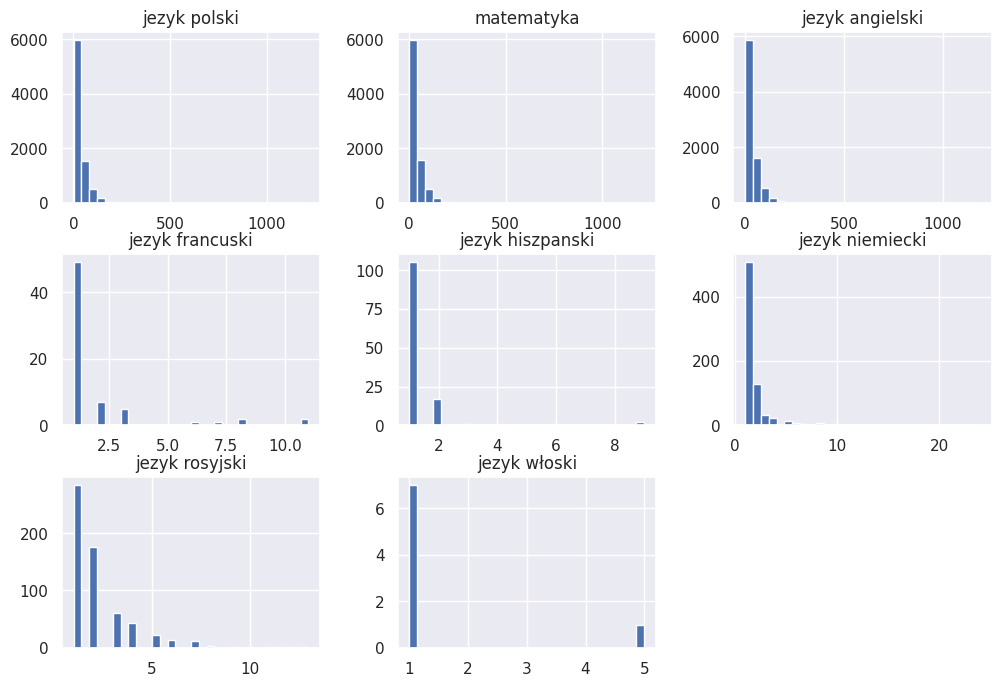

In [8]:
df_liczba_zdajacych.hist(
    bins=30,
    figsize=(12, 8)
)

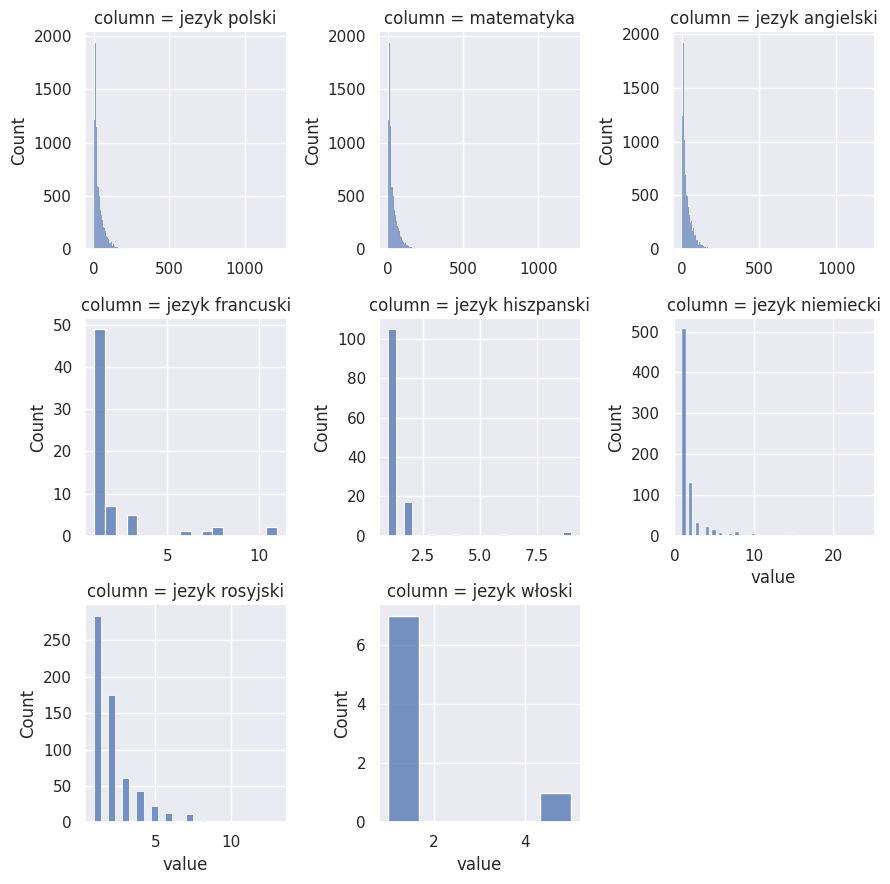

In [9]:
long_df = df_liczba_zdajacych.melt(
    var_name="column",
    value_name="value"
)

g = sns.FacetGrid(
    long_df,
    col="column",
    col_wrap=3,
    sharex=False,
    sharey=False,
)

g.map(sns.histplot, "value")

In [10]:
def get_language_numer_of_students(lang: str):
    return df_liczba_zdajacych['jezyk ' + lang].value_counts().sort_index()
get_language_numer_of_students('niemiecki')    

jezyk niemiecki
1.0     506
2.0     128
3.0      32
4.0      22
5.0      15
6.0       6
7.0       3
8.0       8
9.0       2
10.0      5
11.0      1
12.0      2
14.0      1
15.0      2
20.0      2
24.0      1
Name: count, dtype: int64

In [11]:
get_language_numer_of_students('rosyjski')

jezyk rosyjski
1.0     284
2.0     175
3.0      61
4.0      43
5.0      23
6.0      13
7.0      12
8.0       3
9.0       2
10.0      1
11.0      1
12.0      2
13.0      2
Name: count, dtype: int64

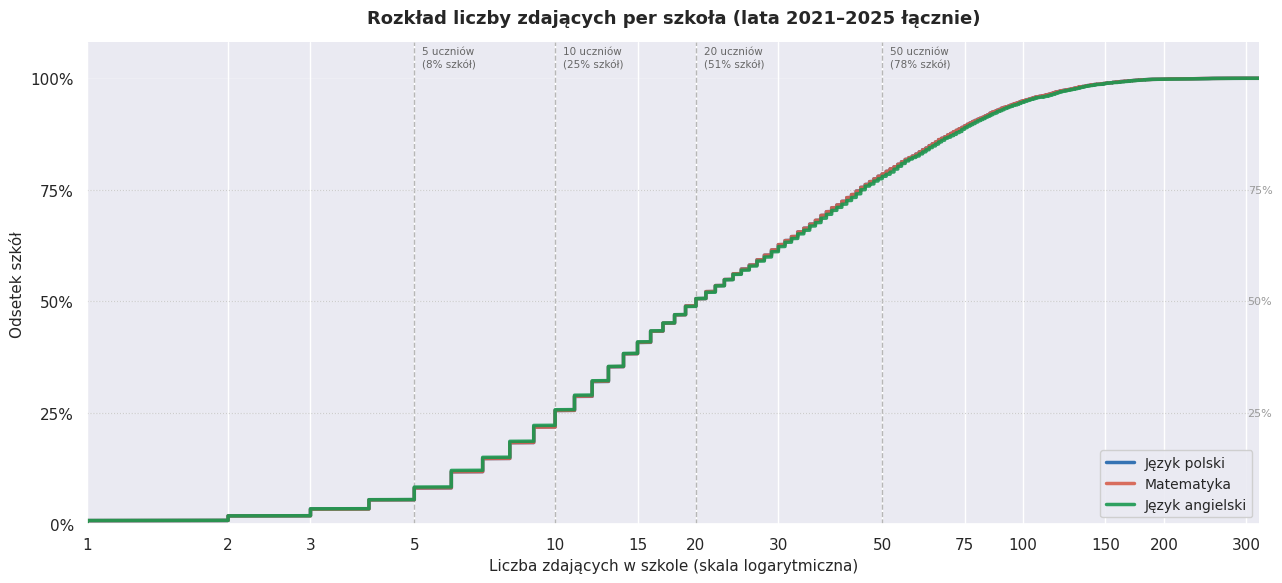

Przedmiot,Rekordów,Mediana zdających,Maks. zdających
J. francuski,67,1,11
J. hiszpanski,127,1,9
J. niemiecki,736,1,24
J. rosyjski,622,2,13
J. włoski,8,1,5


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
 
# ── konfiguracja ──────────────────────────────────────────────────────────────
GLOWNE   = ["jezyk polski", "matematyka", "jezyk angielski"]
MALE     = ["jezyk francuski", "jezyk hiszpanski", "jezyk niemiecki",
            "jezyk rosyjski", "jezyk włoski"]
KOLORY   = {"jezyk polski": "#2166ac", "matematyka": "#d6604d",
            "jezyk angielski": "#1a9850"}
ETYKIETY = {"jezyk polski": "Język polski", "matematyka": "Matematyka",
            "jezyk angielski": "Język angielski"}
 
# progi z adnotacjami (x, etykieta)
PROGI = [
    (5,  "5 uczniów\n(8% szkół)"),
    (10, "10 uczniów\n(25% szkół)"),
    (20, "20 uczniów\n(51% szkół)"),
    (50, "50 uczniów\n(78% szkół)"),
]
 
# ── helper: ECDF ──────────────────────────────────────────────────────────────
def ecdf(series: pd.Series):
    """Zwraca (x, y) posortowane wartości i ich skumulowany odsetek (0–100)."""
    x = np.sort(series.dropna().values)
    y = np.arange(1, len(x) + 1) / len(x) * 100
    return x, y
 
# ── wykres główny ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
 
for kolumna in GLOWNE:
    if kolumna not in df_liczba_zdajacych.columns:
        continue
    x, y = ecdf(df_liczba_zdajacych[kolumna])
    ax.plot(x, y,
            label=ETYKIETY[kolumna],
            color=KOLORY[kolumna],
            linewidth=2.5,
            alpha=0.9)
 
# progi pionowe
for prog_x, prog_label in PROGI:
    ax.axvline(prog_x, color="#999999", linestyle="--", linewidth=1, alpha=0.7, zorder=1)
    ax.text(prog_x * 1.04, 102, prog_label,
            fontsize=7.5, color="#666666", va="bottom", ha="left", linespacing=1.4)
 
# progi poziome
for prog_y in [25, 50, 75]:
    ax.axhline(prog_y, color="#cccccc", linestyle=":", linewidth=0.8, zorder=1)
    ax.text(302, prog_y, f"{prog_y}%",
            fontsize=8, color="#999999", va="center", ha="left")
 
# oś X — log, ręczne ticki żeby pokazać liczby a nie potęgi
ax.set_xscale("log")
ticki = [1, 2, 3, 5, 10, 15, 20, 30, 50, 75, 100, 150, 200, 300]
ax.set_xticks(ticki)
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax.set_xlim(1, 320)
 
# oś Y
ax.set_ylim(0, 108)
ax.set_yticks([0, 25, 50, 75, 100])
ax.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))
 
ax.set_xlabel("Liczba zdających w szkole (skala logarytmiczna)", fontsize=11)
ax.set_ylabel("Odsetek szkół", fontsize=11)
ax.set_title("Rozkład liczby zdających per szkoła (lata 2021–2025 łącznie)",
             fontsize=13, fontweight="bold", pad=14)
 
ax.legend(loc="lower right", fontsize=10, framealpha=0.9)
ax.grid(axis="y", alpha=0.2)
ax.spines[["top", "right"]].set_visible(False)
 
plt.tight_layout()
plt.show()
 
# ── tabela dla małych języków ─────────────────────────────────────────────────
wiersze = []
for kolumna in MALE:
    if kolumna not in df_liczba_zdajacych.columns:
        continue
    s = df_liczba_zdajacych[kolumna].dropna()
    s = s[s > 0]
    wiersze.append({
        "Przedmiot":        kolumna.replace("jezyk ", "j. ").capitalize(),
        "Rekordów":         len(s),
        "Mediana zdających": int(s.median()),
        "Maks. zdających":  int(s.max()),
    })
 
tabela = pd.DataFrame(wiersze)
display(tabela.style
        .set_caption("Języki obce mniejszościowe — zbyt mało danych na ECDF")
        .hide(axis="index"))

Poza EN i PL inne języki dość mało zdających (a to przecież zbiór na przestrzeni co najmniej 5 lat), więc usuniemy te kolumny ze zbioru danych i dalszej analizy.

In [13]:
df_egzaminy_all = df_egzaminy.copy()
df_egzaminy = df_egzaminy[['meta'] + GLOWNE]
df_egzaminy

obszar   meta                                                          \
metryka   rok id oke wojewodztwo - nazwa powiat - nazwa gmina - nazwa   
0        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
1        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
2        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
3        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
4        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
...       ...    ...                 ...            ...           ...   
8255     2025      7         Mazowieckie    Żyrardowski      Żyrardów   
8256     2025      7         Mazowieckie    Żyrardowski      Żyrardów   
8257     2025      7         Mazowieckie    Żyrardowski      Żyrardów   
8258     2025      7         Mazowieckie    Żyrardowski      Żyrardów   
8259     2025      7         Mazowieckie    Żyrardowski      Żyrardów   

obszar                                                                        \
metryka      typ gminy kod teryt gminy    rspo rodzaj placowki czy publiczna   
0        Gmina miejska         1461011   27152   dla młodzieży           Tak   
1        Gmina miejska         1461011   27351   dla młodzieży           Tak   
2        Gmina miejska         1461011   27789   dla młodzieży           Tak   
3        Gmina miejska         1461011   44013   dla młodzieży           Tak   
4        Gmina miejska         1461011   44015   dla młodzieży           Tak   
...                ...             ...     ...             ...           ...   
8255     Gmina miejska         1438011   34206   dla młodzieży           Tak   
8256     Gmina miejska         1438011   31353   dla młodzieży           Tak   
8257     Gmina miejska         1438011   29970   dla młodzieży           Tak   
8258     Gmina miejska         1438011   30368   dla młodzieży           Tak   
8259     Gmina miejska         1438011  264325   dla młodzieży           Nie   

obszar   ...       matematyka                                              \
metryka  ... liczba zdajacych wynik sredni (%) odchylenie standardowe (%)   
0        ...             48.0        43.000000                  25.066578   
1        ...             84.0        42.714286                  25.953517   
2        ...            131.0        49.160305                  24.401169   
3        ...             91.0        52.175824                  25.102250   
4        ...             66.0        44.181818                  25.654410   
...      ...              ...              ...                        ...   
8255     ...             55.0        47.254545                  30.705178   
8256     ...             62.0        52.467742                  28.690629   
8257     ...             42.0        62.523810                  30.254664   
8258     ...             30.0        24.333333                  24.054568   
8259     ...             18.0        80.611111                  21.074310   

obszar                           jezyk angielski                   \
metryka mediana (%) modalna (%) liczba zdajacych wynik sredni (%)   
0              38.0        56.0             50.0        58.460000   
1              38.0        20.0             83.0        64.192771   
2              48.0        68.0            132.0        78.098485   
3              48.0        20.0             91.0        73.747253   
4              44.0        16.0             64.0        65.531250   
...             ...         ...              ...              ...   
8255           50.0        17.0             55.0        68.072727   
8256           57.0        57.0             62.0        73.032258   
8257           75.0        13.0             42.0        79.952381   
8258           17.0        10.0             33.0        50.363636   
8259           87.0       100.0             18.0        93.611111   

obszar                                                      
metryka odchylenie standardowe (%) mediana (%) m

In [14]:
df_egzaminy[GLOWNE]

obszar      jezyk polski                                              \
metryka liczba zdajacych wynik sredni (%) odchylenie standardowe (%)   
0                   48.0        51.916667                  19.542511   
1                   84.0        51.464286                  19.891639   
2                  131.0        65.404580                  17.629685   
3                   91.0        60.912088                  18.829862   
4                   66.0        59.151515                  20.470409   
...                  ...              ...                        ...   
8255                55.0        65.018182                  20.576678   
8256                62.0        64.693548                  16.928301   
8257                42.0        70.619048                  12.141923   
8258                30.0        53.466667                  18.927464   
8259                18.0        81.222222                   7.778571   

obszar                                matematyka                   \
metryka mediana (%) modalna (%) liczba zdajacych wynik sredni (%)   
0              56.0        62.0             48.0        43.000000   
1              53.0        47.0             84.0        42.714286   
2              69.0        71.0            131.0        49.160305   
3              62.0        62.0             91.0        52.175824   
4              62.0        62.0             66.0        44.181818   
...             ...         ...              ...              ...   
8255           69.0        67.0             55.0        47.254545   
8256           69.0        69.0             62.0        52.467742   
8257           71.0        62.0             42.0        62.523810   
8258           54.5        60.0             30.0        24.333333   
8259           82.0        84.0             18.0        80.611111   

obszar                                                      jezyk angielski  \
metryka odchylenie standardowe (%) mediana (%) modalna (%) liczba zdajacych   
0                        25.066578        38.0        56.0             50.0   
1                        25.953517        38.0        20.0             83.0   
2                        24.401169        48.0        68.0            132.0   
3                        25.102250        48.0        20.0             91.0   
4                        25.654410        44.0        16.0             64.0   
...                            ...         ...         ...              ...   
8255                     30.705178        50.0        17.0             55.0   
8256                     28.690629        57.0        57.0             62.0   
8257                     30.254664        75.0        13.0             42.0   
8258                     24.054568        17.0        10.0             33.0   
8259                     21.074310        87.0       100.0             18.0   

obszar                                                                       
metryka wynik sredni (%) odchylenie standardowe (%) mediana (%) modalna (%)  
0              58.460000                  30.962048        46.5        95.0  
1              64.192771                  31.028342        75.0       100.0  
2              78.098485                  24.024880        90.0        96.0  
3              73.747253                  26.438647        84.0       100.0  
4              65.531250                  28.021738        70.0       100.0  
...                  ...                        ...         ...         ...  
8255           68.072727                  30.441511        82.0        96.0  
8256           73.032258                  25.828196        83.0        98.0  
8257           79.952381                  22.273145        91.0        96.0  
8258           50.363636                  32.838280        35.0        16.0  
8259           93.611111                   9.917095        96.0       100.0  

[8260 rows x 15 columns]

In [15]:
GLOWNE

['jezyk polski', 'matematyka', 'jezyk angielski']

In [16]:
df_egzaminy['matematyka'].columns

Index(['liczba zdajacych', 'wynik sredni (%)', 'odchylenie standardowe (%)',
       'mediana (%)', 'modalna (%)'],
      dtype='str', name='metryka')

In [17]:
# Dodaj mediana - średnia
MEDIANA_MINUS_SREDNIA = 'mediana - srednia'
for obszar in GLOWNE:    
    df_egzaminy[(obszar, MEDIANA_MINUS_SREDNIA)] = df_egzaminy[(obszar, 'mediana (%)')] - df_egzaminy[(obszar, 'wynik sredni (%)')]
df_egzaminy['matematyka']    

metryka,liczba zdajacych,wynik sredni (%),odchylenie standardowe (%),mediana (%),modalna (%),mediana - srednia
0,48.0,43.000000,25.066578,38.0,56.0,-5.000000
1,84.0,42.714286,25.953517,38.0,20.0,-4.714286
2,131.0,49.160305,24.401169,48.0,68.0,-1.160305
3,91.0,52.175824,25.102250,48.0,20.0,-4.175824
4,66.0,44.181818,25.654410,44.0,16.0,-0.181818
...,...,...,...,...,...,...
8255,55.0,47.254545,30.705178,50.0,17.0,2.745455
8256,62.0,52.467742,28.690629,57.0,57.0,4.532258
8257,42.0,62.523810,30.254664,75.0,13.0,12.476190
8258,30.0,24.333333,24.054568,17.0,10.0,-7.333333


In [18]:


df_egzaminy[['matematyka']].matematyka

metryka,liczba zdajacych,wynik sredni (%),odchylenie standardowe (%),mediana (%),modalna (%),mediana - srednia
0,48.0,43.000000,25.066578,38.0,56.0,-5.000000
1,84.0,42.714286,25.953517,38.0,20.0,-4.714286
2,131.0,49.160305,24.401169,48.0,68.0,-1.160305
3,91.0,52.175824,25.102250,48.0,20.0,-4.175824
4,66.0,44.181818,25.654410,44.0,16.0,-0.181818
...,...,...,...,...,...,...
8255,55.0,47.254545,30.705178,50.0,17.0,2.745455
8256,62.0,52.467742,28.690629,57.0,57.0,4.532258
8257,42.0,62.523810,30.254664,75.0,13.0,12.476190
8258,30.0,24.333333,24.054568,17.0,10.0,-7.333333


In [19]:
df_matematyka = df_egzaminy[['matematyka']].matematyka
df_egzaminy[df_matematyka['liczba zdajacych'] > 300]

obszar   meta                                                          \
metryka   rok id oke wojewodztwo - nazwa powiat - nazwa gmina - nazwa   
4725     2023      7         Mazowieckie       Warszawa      Warszawa   
6320     2024      7         Mazowieckie       Warszawa      Warszawa   
7967     2025      7         Mazowieckie       Warszawa      Warszawa   

obszar                                                                        \
metryka      typ gminy kod teryt gminy    rspo rodzaj placowki czy publiczna   
4725     Gmina miejska         1465011  131706   dla młodzieży           Nie   
6320     Gmina miejska         1465011  131706   dla młodzieży           Nie   
7967     Gmina miejska         1465011  131706   dla młodzieży           Nie   

obszar   ...  matematyka              jezyk angielski                   \
metryka  ... mediana (%) modalna (%) liczba zdajacych wynik sredni (%)   
4725     ...        32.0        20.0           1187.0        72.826453   
6320     ...        28.0        24.0            956.0        71.105649   
7967     ...        20.0        10.0            507.0        69.319527   

obszar                                                          jezyk polski  \
metryka odchylenie standardowe (%) mediana (%) modalna (%) mediana - srednia   
4725                     26.860089        85.0        95.0          4.582716   
6320                     27.826200        82.0        98.0          3.436105   
7967                     29.046390        82.0        95.0          2.146947   

obszar         matematyka   jezyk angielski  
metryka mediana - srednia mediana - srednia  
4725            -9.073892         12.173547  
6320            -7.768057         10.894351  
7967            -8.765714         12.680473  

[3 rows x 31 columns]

In [20]:
# Diagnostyka struktury df_egzaminy
print("Typ kolumn:", type(df_egzaminy.columns))
print()
print("Pierwsze 25 kolumn:")
for i, col in enumerate(df_egzaminy.columns[:25]):
    print(f"  {i:2d}: {col}")
print()
print("Shape:", df_egzaminy.shape)
print()
print("Pierwsze 2 wiersze (pierwsze 8 kolumn):")
print(df_egzaminy.iloc[:2, :8])

Typ kolumn: <class 'pandas.MultiIndex'>

Pierwsze 25 kolumn:
   0: ('meta', 'rok')
   1: ('meta', 'id oke')
   2: ('meta', 'wojewodztwo - nazwa')
   3: ('meta', 'powiat - nazwa')
   4: ('meta', 'gmina - nazwa')
   5: ('meta', 'typ gminy')
   6: ('meta', 'kod teryt gminy')
   7: ('meta', 'rspo')
   8: ('meta', 'rodzaj placowki')
   9: ('meta', 'czy publiczna')
  10: ('meta', 'nazwa szkoły')
  11: ('meta', 'miejscowosc')
  12: ('meta', 'ulica nr')
  13: ('jezyk polski', 'liczba zdajacych')
  14: ('jezyk polski', 'wynik sredni (%)')
  15: ('jezyk polski', 'odchylenie standardowe (%)')
  16: ('jezyk polski', 'mediana (%)')
  17: ('jezyk polski', 'modalna (%)')
  18: ('matematyka', 'liczba zdajacych')
  19: ('matematyka', 'wynik sredni (%)')
  20: ('matematyka', 'odchylenie standardowe (%)')
  21: ('matematyka', 'mediana (%)')
  22: ('matematyka', 'modalna (%)')
  23: ('jezyk angielski', 'liczba zdajacych')
  24: ('jezyk angielski', 'wynik sredni (%)')

Shape: (8260, 31)

Pierwsze 2 wiersze

In [21]:
df_egzaminy

obszar   meta                                                          \
metryka   rok id oke wojewodztwo - nazwa powiat - nazwa gmina - nazwa   
0        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
1        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
2        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
3        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
4        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
...       ...    ...                 ...            ...           ...   
8255     2025      7         Mazowieckie    Żyrardowski      Żyrardów   
8256     2025      7         Mazowieckie    Żyrardowski      Żyrardów   
8257     2025      7         Mazowieckie    Żyrardowski      Żyrardów   
8258     2025      7         Mazowieckie    Żyrardowski      Żyrardów   
8259     2025      7         Mazowieckie    Żyrardowski      Żyrardów   

obszar                                                                        \
metryka      typ gminy kod teryt gminy    rspo rodzaj placowki czy publiczna   
0        Gmina miejska         1461011   27152   dla młodzieży           Tak   
1        Gmina miejska         1461011   27351   dla młodzieży           Tak   
2        Gmina miejska         1461011   27789   dla młodzieży           Tak   
3        Gmina miejska         1461011   44013   dla młodzieży           Tak   
4        Gmina miejska         1461011   44015   dla młodzieży           Tak   
...                ...             ...     ...             ...           ...   
8255     Gmina miejska         1438011   34206   dla młodzieży           Tak   
8256     Gmina miejska         1438011   31353   dla młodzieży           Tak   
8257     Gmina miejska         1438011   29970   dla młodzieży           Tak   
8258     Gmina miejska         1438011   30368   dla młodzieży           Tak   
8259     Gmina miejska         1438011  264325   dla młodzieży           Nie   

obszar   ...  matematyka              jezyk angielski                   \
metryka  ... mediana (%) modalna (%) liczba zdajacych wynik sredni (%)   
0        ...        38.0        56.0             50.0        58.460000   
1        ...        38.0        20.0             83.0        64.192771   
2        ...        48.0        68.0            132.0        78.098485   
3        ...        48.0        20.0             91.0        73.747253   
4        ...        44.0        16.0             64.0        65.531250   
...      ...         ...         ...              ...              ...   
8255     ...        50.0        17.0             55.0        68.072727   
8256     ...        57.0        57.0             62.0        73.032258   
8257     ...        75.0        13.0             42.0        79.952381   
8258     ...        17.0        10.0             33.0        50.363636   
8259     ...        87.0       100.0             18.0        93.611111   

obszar                                                          jezyk polski  \
metryka odchylenie standardowe (%) mediana (%) modalna (%) mediana - srednia   
0                        30.962048        46.5        95.0          4.083333   
1                        31.028342        75.0       100.0          1.535714   
2                        24.024880        90.0        96.0          3.595420   
3                        26.438647        84.0       100.0          1.087912   
4                        28.021738        70.0       100.0          2.848485   
...                            ...         ...         ...               ...   
8255                     30.441511        82.0        96.0          3.981818   
8256                     25.828196        83.0        98.0          4.306452   
8257                     22.273145        91.0        96.0          0.380952   
8258                     32.838280        35.0        16.0          1.033333   
8259                      9.917095        96.0       100.0          0.777778   

obsza

<Axes: xlabel='liczba zdajacych', ylabel='mediana - srednia'>

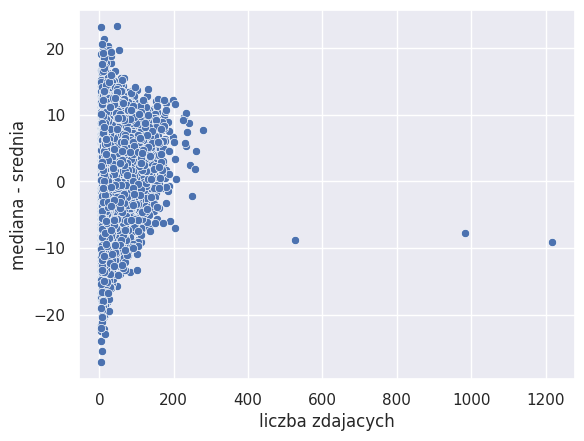

In [22]:
sns.scatterplot(data=df_egzaminy[['matematyka']].matematyka, y=MEDIANA_MINUS_SREDNIA, x='liczba zdajacych')

In [23]:
df_egzaminy_bak = df_egzaminy.copy()

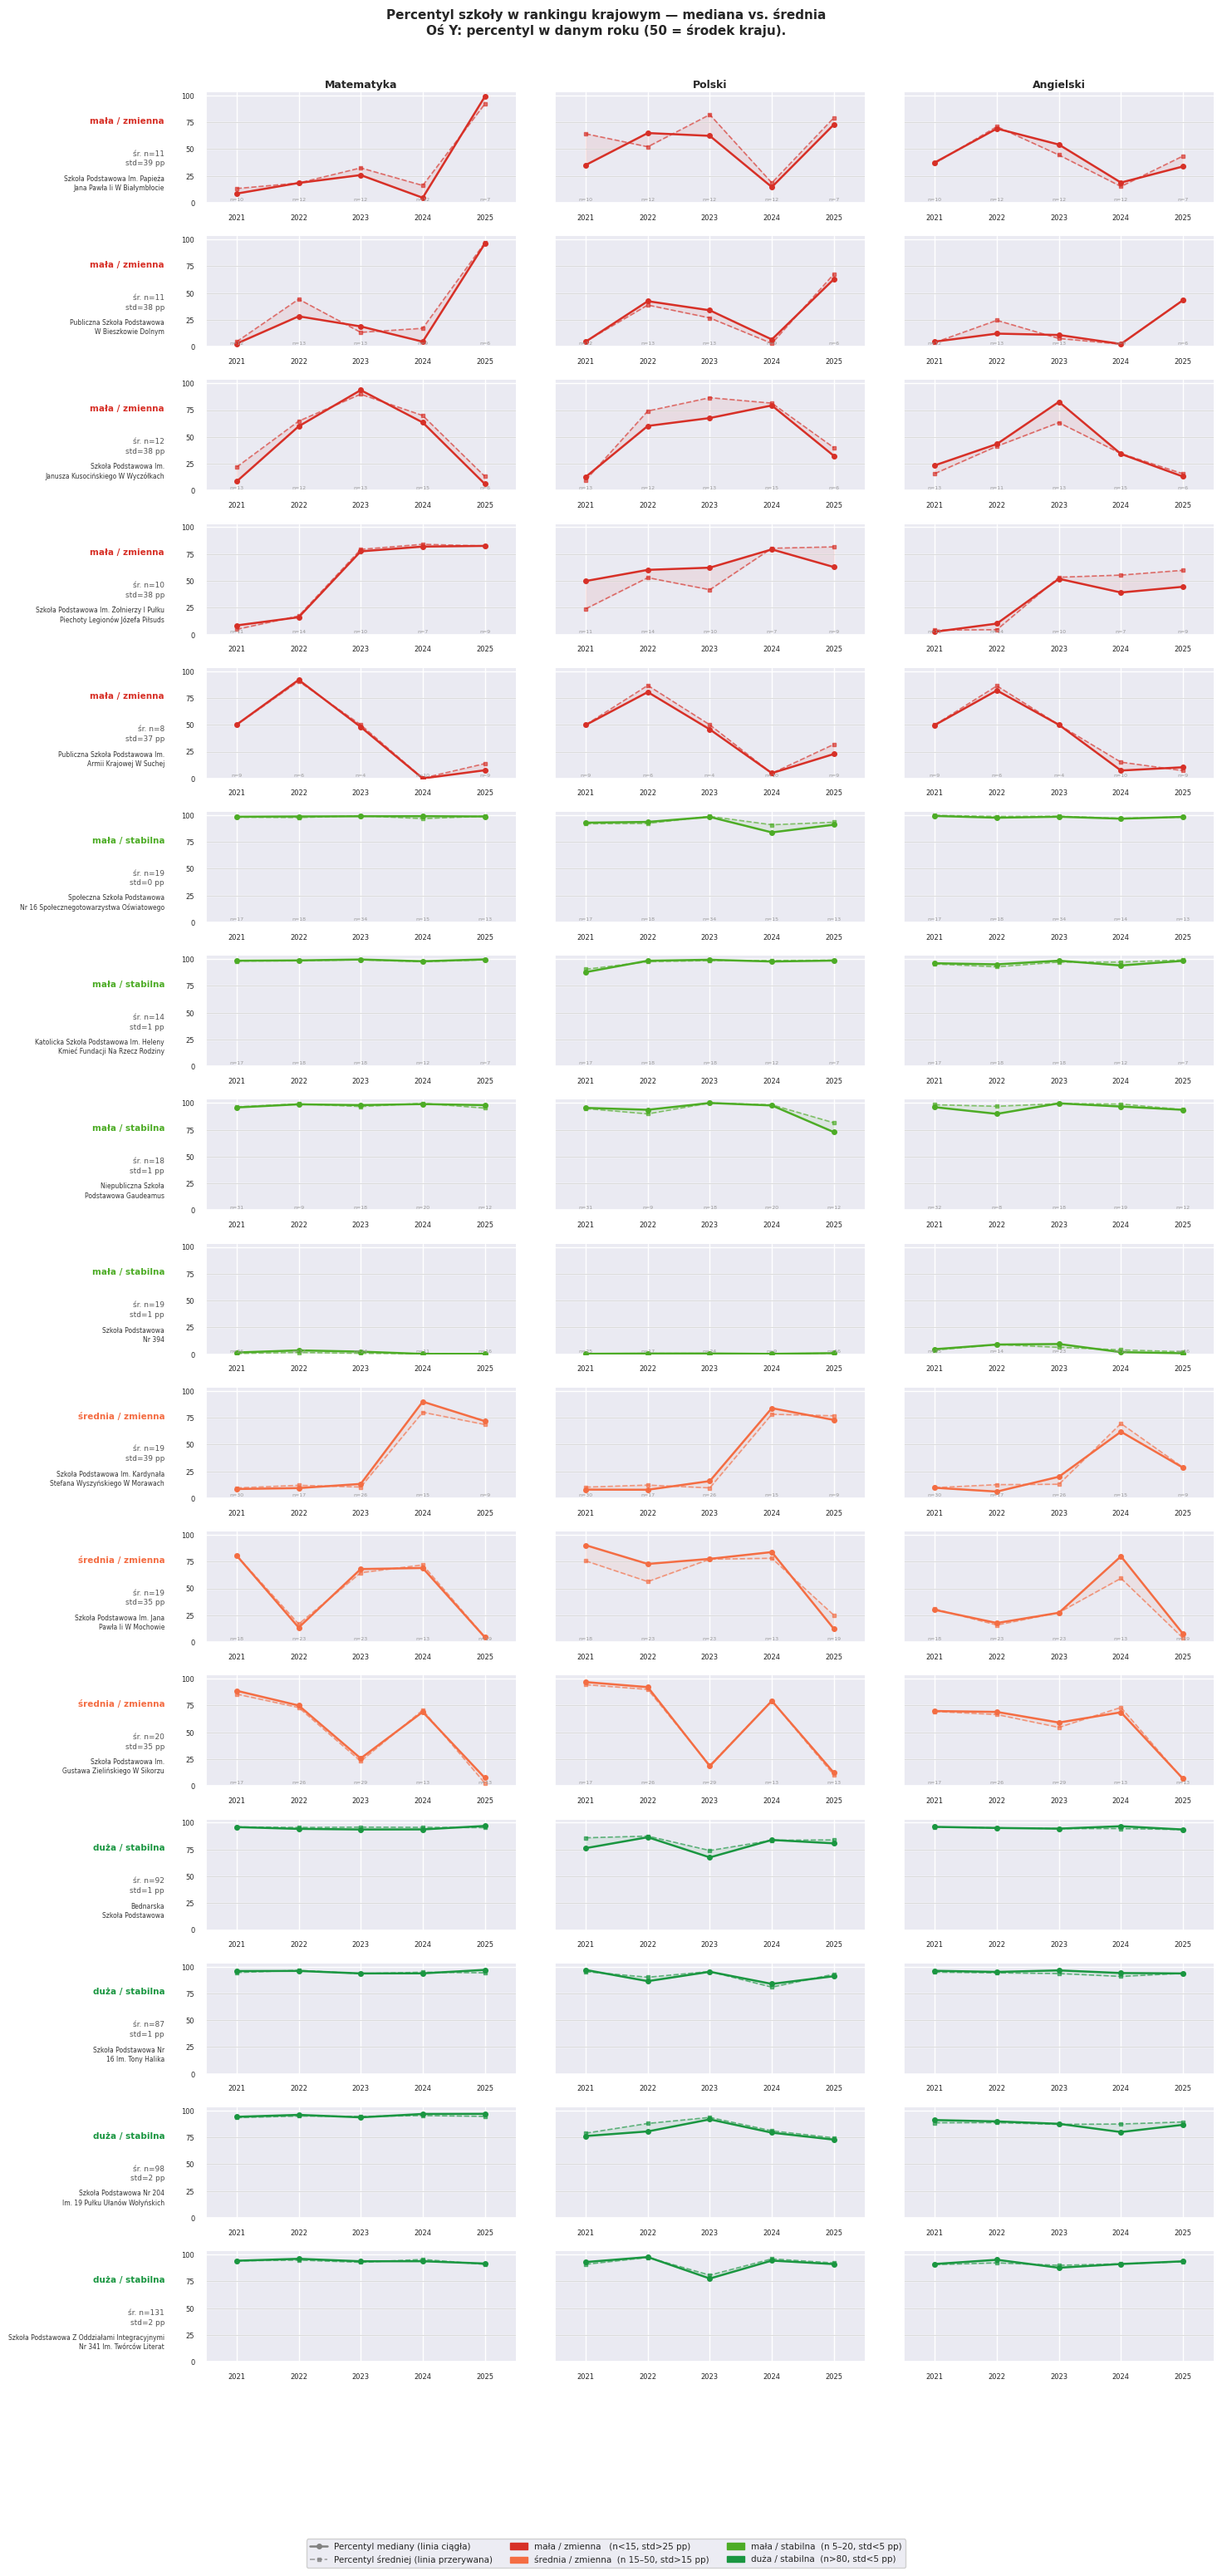

In [24]:
"""
Portrety szkół — percentyl mediany vs. średniej w kolejnych latach.

Wymaga: df_egzaminy z MultiIndex kolumnami:
  ('meta', 'rok'), ('meta', 'rspo'), ('meta', 'nazwa szkoły')
  ('jezyk polski' | 'matematyka' | 'jezyk angielski',
   'liczba zdajacych' | 'mediana (%)' | 'wynik sredni (%)')
Jeden wiersz = jedna szkoła × jeden rok.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from scipy import stats
from pathlib import Path

# ── 1. Wypłaszcz do roboczego DataFrame ───────────────────────────────────────
SUBJ_MAP = {
    'pl':  'jezyk polski',
    'mat': 'matematyka',
    'en':  'jezyk angielski',
}

work = pd.DataFrame({
    'rspo':  df_egzaminy[('meta', 'rspo')],
    'nazwa': df_egzaminy[('meta', 'nazwa szkoły')],
    'rok':   df_egzaminy[('meta', 'rok')],
})

for key, col_name in SUBJ_MAP.items():
    work[f'n_{key}']   = pd.to_numeric(df_egzaminy[(col_name, 'liczba zdajacych')], errors='coerce')
    work[f'med_{key}'] = pd.to_numeric(df_egzaminy[(col_name, 'mediana (%)')],      errors='coerce')
    work[f'avg_{key}'] = pd.to_numeric(df_egzaminy[(col_name, 'wynik sredni (%)')], errors='coerce')

work = work[work['n_mat'].notna() & (work['n_mat'] > 0)].copy()

# ── 2. Percentyl w kraju w obrębie roku, osobno dla mediany i średniej ─────────
for key in SUBJ_MAP:
    for metric in ['med', 'avg']:
        col_in  = f'{metric}_{key}'
        col_out = f'pct_{metric}_{key}'
        work[col_out] = work.groupby('rok')[col_in].transform(
            lambda x: stats.rankdata(x.fillna(x.median()), method='average') / len(x) * 100
        )

# ── 3. Wybierz szkoły z danymi ze wszystkich 5 lat ────────────────────────────
cnt  = work.groupby('rspo')['rok'].nunique()
df5  = work[work['rspo'].isin(cnt[cnt == 5].index)].copy()

mean_n  = df5.groupby('rspo')['n_mat'].mean()
pct_std = df5.groupby('rspo')['pct_med_mat'].std()
name_lu = df5.groupby('rspo')['nazwa'].first()

SPECIAL_KW = ['specjaln', 'dorosłych', 'przysposabiający']
def is_special(rspo):
    return any(k in str(name_lu.get(rspo, '')).lower() for k in SPECIAL_KW)

ok = pd.DataFrame({'mean_n': mean_n, 'pct_std': pct_std})
ok['special'] = ok.index.map(is_special)
ok = ok[~ok['special']]

# ── 4. Dobierz reprezentatywne szkoły ─────────────────────────────────────────
def pick(mask, sort_col, n, ascending=False):
    sub = ok[mask].sort_values(sort_col, ascending=ascending)
    return list(sub.index[:n])

LATA = sorted(work['rok'].unique())

sel = []
sel += [(r, 'mała / zmienna',    '#d73027')
        for r in pick((ok.mean_n < 15) & (ok.pct_std > 25),            'pct_std', 5)]
sel += [(r, 'mała / stabilna',   '#4dac26')
        for r in pick((ok.mean_n.between(5, 20)) & (ok.pct_std < 5),   'pct_std', 4, True)]
sel += [(r, 'średnia / zmienna', '#f46d43')
        for r in pick((ok.mean_n.between(15, 50)) & (ok.pct_std > 15), 'pct_std', 3)]
sel += [(r, 'duża / stabilna',   '#1a9641')
        for r in pick((ok.mean_n > 80) & (ok.pct_std < 5),             'pct_std', 4, True)]

# ── 5. Siatka portretów ───────────────────────────────────────────────────────
SUBJ_LABELS = {'mat': 'Matematyka', 'pl': 'Polski', 'en': 'Angielski'}
NROWS = len(sel)

fig, axes = plt.subplots(
    nrows=NROWS, ncols=4,
    figsize=(15, NROWS * 1.9),
    gridspec_kw={'width_ratios': [0.22, 1, 1, 1]}
)

for row_idx, (rspo, kategoria, kolor) in enumerate(sel):
    school = df5[df5['rspo'] == rspo].sort_values('rok')
    n_avg  = mean_n[rspo]
    std_v  = pct_std[rspo]

    # Skróć nazwę szkoły do 2 linii
    words = str(name_lu.get(rspo, '')).title().split()
    mid   = max(1, len(words) // 2)
    label = (' '.join(words[:mid]) + '\n' + ' '.join(words[mid:]))[:72]

    # --- kolumna 0: etykieta ---
    ax0 = axes[row_idx, 0]
    ax0.axis('off')
    ax0.text(0.97, 0.78, kategoria,
             transform=ax0.transAxes, fontsize=7.5, color=kolor,
             fontweight='bold', ha='right', va='top', linespacing=1.3)
    ax0.text(0.97, 0.48, f'śr. n={n_avg:.0f}\nstd={std_v:.0f} pp',
             transform=ax0.transAxes, fontsize=6.5, color='#555',
             ha='right', va='top', linespacing=1.4)
    ax0.text(0.97, 0.10, label,
             transform=ax0.transAxes, fontsize=5.5, color='#333',
             ha='right', va='bottom', linespacing=1.3)

    # --- kolumny 1–3: przedmioty ---
    for col_idx, (subj_key, subj_name) in enumerate(SUBJ_LABELS.items()):
        ax = axes[row_idx, col_idx + 1]

        y_med = school[f'pct_med_{subj_key}'].values
        y_avg = school[f'pct_avg_{subj_key}'].values
        ns    = school[f'n_{subj_key}'].values

        ax.plot(LATA, y_med, color=kolor, lw=1.8, marker='o', ms=4, zorder=3)
        ax.plot(LATA, y_avg, color=kolor, lw=1.2, marker='s', ms=3,
                ls='--', alpha=0.65, zorder=3)
        ax.fill_between(LATA, y_med, y_avg, color=kolor, alpha=0.08)

        # n= pod każdym punktem dla małych szkół
        if n_avg < 25:
            for x, nv in zip(LATA, ns):
                if not np.isnan(nv):
                    ax.text(x, 1, f'n={int(nv)}', fontsize=4.5,
                            color='#999', ha='center', va='bottom')

        for ref in [25, 50, 75]:
            ax.axhline(ref, color='#ccc', lw=0.5, zorder=1)

        ax.set_xlim(LATA[0] - 0.5, LATA[-1] + 0.5)
        ax.set_ylim(0, 103)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.set_xticks(LATA)
        ax.tick_params(axis='x', labelsize=6)
        ax.tick_params(axis='y', labelsize=6)
        ax.spines[['top', 'right']].set_visible(False)

        if row_idx == 0:
            ax.set_title(subj_name, fontsize=9, fontweight='bold', pad=4)
        if col_idx > 0:
            ax.set_yticklabels([])

# ── 6. Legenda ────────────────────────────────────────────────────────────────
handles = [
    mlines.Line2D([], [], color='gray', lw=1.8, marker='o', ms=4,
                  label='Percentyl mediany (linia ciągła)'),
    mlines.Line2D([], [], color='gray', lw=1.2, marker='s', ms=3,
                  ls='--', alpha=0.7,
                  label='Percentyl średniej (linia przerywana)'),
    mpatches.Patch(color='#d73027', label='mała / zmienna   (n<15, std>25 pp)'),
    mpatches.Patch(color='#f46d43', label='średnia / zmienna  (n 15–50, std>15 pp)'),
    mpatches.Patch(color='#4dac26', label='mała / stabilna  (n 5–20, std<5 pp)'),
    mpatches.Patch(color='#1a9641', label='duża / stabilna  (n>80, std<5 pp)'),
]
fig.legend(handles=handles, loc='lower center', ncol=3,
           fontsize=7.5, framealpha=0.9, bbox_to_anchor=(0.5, -0.01))

fig.suptitle(
    'Percentyl szkoły w rankingu krajowym — mediana vs. średnia\n'
    'Oś Y: percentyl w danym roku (50 = środek kraju).',
    fontsize=11, fontweight='bold', y=1.005
)
plt.tight_layout(rect=[0, 0.06, 1, 1])

output_dir = Path('../outputs')
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / 'portrety_szkol.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
df_egzaminy_by_rspo = df_egzaminy.groupby(('meta', 'rspo'))

## Mediana median szkol w kolejnych latach (PL, matematyka, EN)

Wynik środkowego ucznia w środkowej szkole dość mocno się zmienia z roku na rok.

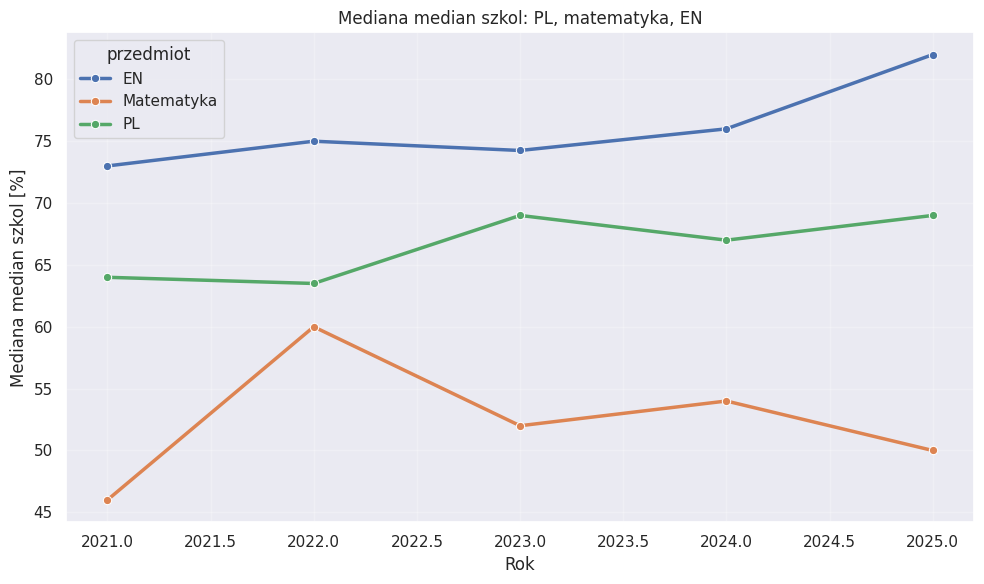

przedmiot,EN,Matematyka,PL
rok,,,
2021,73.00,46.0,64.0
2022,75.00,60.0,63.5
2023,74.25,52.0,69.0
2024,76.00,54.0,67.0
2025,82.00,50.0,69.0


In [26]:
subject_specs = [
    ('PL', ['polski', 'jezyk polski']),
    ('Matematyka', ['matematyka']),
    ('EN', ['angielski', 'jezyk angielski']),
]

serie = []
for label, subject_aliases in subject_specs:
    subject_median_col = get_subject_metric_col(
        column_index,
        subject_aliases=subject_aliases,
        metric_aliases=['mediana'],
    )

    tmp = df_egzaminy[[('meta', 'rok'), subject_median_col]].copy()
    tmp.columns = ['rok', 'mediana_szkoly']
    tmp['mediana_szkoly'] = pd.to_numeric(tmp['mediana_szkoly'], errors='coerce')
    tmp = tmp.dropna(subset=['mediana_szkoly'])

    summary = tmp.groupby('rok', as_index=False)['mediana_szkoly'].median()
    summary['przedmiot'] = label
    serie.append(summary)

mediana_median_rocznie = pd.concat(serie, ignore_index=True).sort_values(['rok', 'przedmiot'])

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=mediana_median_rocznie,
    x='rok',
    y='mediana_szkoly',
    hue='przedmiot',
    marker='o',
    linewidth=2.5,
)
plt.xlabel('Rok')
plt.ylabel('Mediana median szkol [%]')
plt.title('Mediana median szkol: PL, matematyka, EN')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

mediana_median_rocznie.pivot(index='rok', columns='przedmiot', values='mediana_szkoly')

## Dalej

`df_egzaminy` jest gotowy ze sprawdzonym formatem oraz kolumnami 2-poziomowymi (`MultiIndex`).
Kolumna roku to `('meta', 'rok')` i mozesz na tym od razu robic dalsze analizy.

In [27]:
df_egzaminy.head()

obszar   meta                                                          \
metryka   rok id oke wojewodztwo - nazwa powiat - nazwa gmina - nazwa   
0        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
1        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
2        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
3        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   
4        2021      7         Mazowieckie      Ostrołęka     Ostrołęka   

obszar                                                                       \
metryka      typ gminy kod teryt gminy   rspo rodzaj placowki czy publiczna   
0        Gmina miejska         1461011  27152   dla młodzieży           Tak   
1        Gmina miejska         1461011  27351   dla młodzieży           Tak   
2        Gmina miejska         1461011  27789   dla młodzieży           Tak   
3        Gmina miejska         1461011  44013   dla młodzieży           Tak   
4        Gmina miejska         1461011  44015   dla młodzieży           Tak   

obszar   ...  matematyka              jezyk angielski                   \
metryka  ... mediana (%) modalna (%) liczba zdajacych wynik sredni (%)   
0        ...        38.0        56.0             50.0        58.460000   
1        ...        38.0        20.0             83.0        64.192771   
2        ...        48.0        68.0            132.0        78.098485   
3        ...        48.0        20.0             91.0        73.747253   
4        ...        44.0        16.0             64.0        65.531250   

obszar                                                          jezyk polski  \
metryka odchylenie standardowe (%) mediana (%) modalna (%) mediana - srednia   
0                        30.962048        46.5        95.0          4.083333   
1                        31.028342        75.0       100.0          1.535714   
2                        24.024880        90.0        96.0          3.595420   
3                        26.438647        84.0       100.0          1.087912   
4                        28.021738        70.0       100.0          2.848485   

obszar         matematyka   jezyk angielski  
metryka mediana - srednia mediana - srednia  
0               -5.000000        -11.960000  
1               -4.714286         10.807229  
2               -1.160305         11.901515  
3               -4.175824         10.252747  
4               -0.181818          4.468750  

[5 rows x 31 columns]

In [28]:
df_egzaminy.columns

MultiIndex([(           'meta',                        'rok'),
            (           'meta',                     'id oke'),
            (           'meta',        'wojewodztwo - nazwa'),
            (           'meta',             'powiat - nazwa'),
            (           'meta',              'gmina - nazwa'),
            (           'meta',                  'typ gminy'),
            (           'meta',            'kod teryt gminy'),
            (           'meta',                       'rspo'),
            (           'meta',            'rodzaj placowki'),
            (           'meta',              'czy publiczna'),
            (           'meta',               'nazwa szkoły'),
            (           'meta',                'miejscowosc'),
            (           'meta',                   'ulica nr'),
            (   'jezyk polski',           'liczba zdajacych'),
            (   'jezyk polski',           'wynik sredni (%)'),
            (   'jezyk polski', 'odchylenie standardowe

In [29]:
# Podglad wybranej czesci kolumn MultiIndex (po sortowaniu osi kolumn).
df_egzaminy.sort_index(axis=1).loc[:, 'meta':'jezyk angielski']

0
1
2
3
4
...
8255
8256
8257
8258
8259
